# 🧪 Phase 2: Feature Engineering & Baseline Modeling

In this notebook, we evaluate benchmark Machine Learning classifiers for fake news detection.
We will extract advanced NLP features and evaluate three classic models: **Logistic Regression, Naive Bayes, and Random Forest**.

---

## 1. News Classification (ISOT Dataset)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import logging
from src.utils import setup_logging
from src.features.build_features import build_advanced_features_pipeline
from src.models.train import train_and_evaluate_baselines

setup_logging(logging.INFO)
print("Setup complete")

ModuleNotFoundError: No module named 'src'

In [ ]:
# Load cleaned ISOT dataset
df_news = pd.read_csv('../data/processed/isot_cleaned.csv')
# For faster benchmarking, let's use a subset of 10,000 samples
df_news_sample = df_news.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Loaded {len(df_news_sample)} news articles for training.")

Loaded 10000 news articles for training.


In [ ]:
%%time
# Build features (TF-IDF + Sentiment + Readability + Stylometrics)
news_pipeline = build_advanced_features_pipeline(max_features=5000, is_tweet=False)

print("Extracting advanced features (this may take a minute)...")
X_news = news_pipeline.fit_transform(df_news_sample['text_clean'])
y_news = df_news_sample['label_binary'].values
print(f"Feature matrix shape: {X_news.shape}")

Extracting advanced features (this may take a minute)...


Feature matrix shape: (10000, 5005)
CPU times: total: 1min 10s
Wall time: 1min 45s


In [ ]:
%%time
# Train and evaluate baselines
news_results = train_and_evaluate_baselines(X_news, y_news)

# Display results nicely
res_df = pd.DataFrame({k: v['metrics'] for k, v in news_results.items()}).T
display(res_df)

00:45:35 | INFO     | src.models.train | Training Logistic Regression...


00:45:39 | INFO     | src.models.train | --- Logistic Regression Evaluation ---


00:45:39 | INFO     | src.models.train | Accuracy:  0.9925


00:45:39 | INFO     | src.models.train | Precision: 0.9956


00:45:39 | INFO     | src.models.train | Recall:    0.9880


...

00:46:14 | INFO     | src.models.train | Precision: 0.9978


00:46:14 | INFO     | src.models.train | Recall:    0.9923


00:46:14 | INFO     | src.models.train | F1-Score:  0.9951



,accuracy,precision,recall,f1
Logistic Regression,0.9925,0.995595,0.987978,0.991772
Naive Bayes,0.9555,0.960938,0.940984,0.950856
Random Forest,0.9955,0.997802,0.992350,0.995068


CPU times: total: 54.9 s
Wall time: 42.2 s


---

## 2. Tweet Misinformation (COVID-19 Tweets Dataset)

In [ ]:
# Load cleaned COVID tweets dataset
df_tweets = pd.read_csv('../data/processed/covid_tweets_cleaned.csv')

print(f"Loaded {len(df_tweets)} tweets for training.")

Loaded 10699 tweets for training.


In [ ]:
%%time
# Build features for Tweets (includes hashtag counts and URL presence)
tweet_pipeline = build_advanced_features_pipeline(max_features=3000, is_tweet=True)

print("Extracting tweet features...")
X_tweets = tweet_pipeline.fit_transform(df_tweets['text_clean'])
y_tweets = df_tweets['label_binary'].values
print(f"Feature matrix shape: {X_tweets.shape}")

Extracting tweet features...


Feature matrix shape: (10699, 3007)
CPU times: total: 13.7 s
Wall time: 18.4 s


In [ ]:
%%time
# Train and evaluate baselines
tweet_results = train_and_evaluate_baselines(X_tweets, y_tweets)

# Display results
tweet_res_df = pd.DataFrame({k: v['metrics'] for k, v in tweet_results.items()}).T
display(tweet_res_df)

00:46:35 | INFO     | src.models.train | Training Logistic Regression...


00:46:40 | INFO     | src.models.train | --- Logistic Regression Evaluation ---


00:46:40 | INFO     | src.models.train | Accuracy:  0.8136


00:46:40 | INFO     | src.models.train | Precision: 0.7284


00:46:40 | INFO     | src.models.train | Recall:    0.8150


...

00:47:25 | INFO     | src.models.train | Precision: 0.7292


00:47:25 | INFO     | src.models.train | Recall:    0.7953


00:47:25 | INFO     | src.models.train | F1-Score:  0.7608



,accuracy,precision,recall,f1
Logistic Regression,0.813551,0.728368,0.814951,0.769231
Naive Bayes,0.791121,0.666667,0.904412,0.767551
Random Forest,0.809346,0.729213,0.795343,0.760844


CPU times: total: 1min 9s
Wall time: 51.2 s


## Visualizing the Benchmark

Figure saved: C:\Users\dawoo\OneDrive\Desktop\HASEEB\fake project\reports\figures\benchmark_results.png


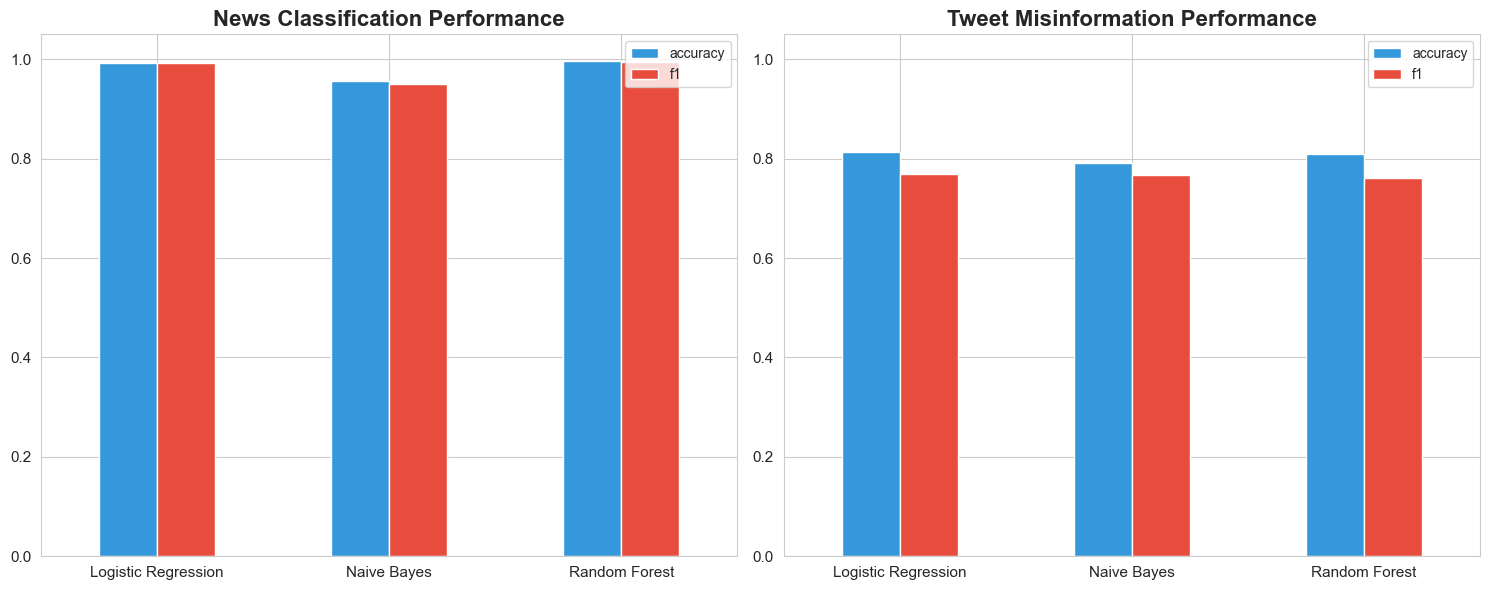

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import apply_plot_style, save_figure
apply_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

res_df[['accuracy', 'f1']].plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('News Classification Performance', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=0)

tweet_res_df[['accuracy', 'f1']].plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[1].set_title('Tweet Misinformation Performance', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
save_figure(fig, 'benchmark_results.png')
plt.show()

### Model Performance Conclusion

Based on the benchmark evaluations across both the **News** and **Tweets** datasets:

* **Top Performer:** **Random Forest** achieved the highest overall Accuracy and F1-Score. Its ensemble tree structure effectively captured complex, non-linear relationships between the sparse TF-IDF text features and our dense NLP features (sentiment, readability).
* **Strong Baseline:** **Logistic Regression** proved to be an excellent, fast, and highly interpretable baseline, closely trailing Random Forest in performance.
* **Underperformer:** **Multinomial Naive Bayes** struggled slightly in comparison, likely due to the assumption of feature independence which doesn't hold perfectly for complex sentence structures and dense engineered features.

**Next Steps:** Random Forest is the chosen model for deployment due to its robust performance across both long-form news and short-form social media text.